In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

2026-04-29 16:12:22.020857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777459342.042834 1152586 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777459342.050254 1152586 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777459342.067193 1152586 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777459342.067215 1152586 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777459342.067217 1152586 computation_placer.cc:177] computation placer alr

In [2]:
# 1. Configuration
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

img_size = 224
batch_size = 32
num_classes = 7
input_shape = (img_size, img_size, 3)

# Use hydrophobicity TRAIN data here
data_path = r"/home/22EC1102/soumen/satarupa/hydrophobicity/Hydrophobicity Classes Photos/train"

# Teacher model path
teacher_model_path = "/home/22EC1102/soumen/satarupa/hydrophobicity/teacher_model_mobilenetv3.keras"

In [3]:
# CELL 2: GPU + mixed precision (critical order)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    tf.config.set_logical_device_configuration(
        gpus[0],
        [tf.config.LogicalDeviceConfiguration(memory_limit=6000)]  # 4GB limit
    )
    print("✅ GPU memory growth + 4GB limit set!")


✅ GPU memory growth + 4GB limit set!


In [4]:
# CELL 5: DATA GENERATION
# IDENTICAL preprocessing settings to teacher_model_hydrophobisity.ipynb train_datagen

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# IMPORTANT:
# Use shuffle=False so confidence scores keep a stable mapping to filenames.
# This differs from teacher training notebook's shuffle=True, but is necessary
# for saving datapoint-wise results correctly. The augmentation pipeline itself
# remains identical.

train_data = train_datagen.flow_from_directory(
    data_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False,
    seed=SEED
)

print("Found samples:", train_data.samples)
print("Class indices:", train_data.class_indices)
class_names = list(train_data.class_indices.keys())
print("Class names:", class_names)

Found 2800 images belonging to 7 classes.
Found samples: 2800
Class indices: {'HC1': 0, 'HC2': 1, 'HC3': 2, 'HC4': 3, 'HC5': 4, 'HC6': 5, 'HC7': 6}
Class names: ['HC1', 'HC2', 'HC3', 'HC4', 'HC5', 'HC6', 'HC7']


In [5]:
# 3. Check one batch

images, labels = train_data[0]

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Single image shape:", images[0].shape)
print("Single label:", labels[0])

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 7)
Single image shape: (224, 224, 3)
Single label: [1. 0. 0. 0. 0. 0. 0.]


In [7]:
# 4. Load Teacher Model

teacher_model = keras.models.load_model(teacher_model_path)
print("Teacher model loaded successfully.")
teacher_model.summary()

I0000 00:00:1777459667.763203 1152586 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6000 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:37:00.0, compute capability: 7.0
I0000 00:00:1777459667.793786 1152586 cuda_executor.cc:479] failed to allocate 5.86GiB (6291456000 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1777459667.793975 1152586 cuda_executor.cc:479] failed to allocate 5.27GiB (5662310400 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1777459667.794117 1152586 cuda_executor.cc:479] failed to allocate 4.75GiB (5096079360 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1777459667.794265 1152586 cuda_executor.cc:479] failed to allocate 4.27GiB (4586471424 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1777459667.794456 1152586 cuda_e

Teacher model loaded successfully.


Model: "teacher_mobilenetv3_hydrophobicity"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,749,527 (14.30 MB)

 Trainable params: 250,247 (977.53 KB)

 Non-trainable params: 2,998,784 (11.44 MB)

 Optimizer params: 500,496 (1.91 MB)

In [8]:
# CELL 6: MC DROPOUT FUNCTION FOR DATA POINT-WISE CONFIDENCE

def mc_dropout_predict_batchwise(model, generator, n_iter=50):
    """
    Returns data point-wise confidence values using MC Dropout.
    Confidence = 1 - max(std across classes) for each sample
    """
    all_sample_confidence = []

    total_batches = len(generator)
    start_time = time.time()

    for batch_idx in range(total_batches):
        X_batch, _ = generator[batch_idx]

        preds = []
        for _ in range(n_iter):
            pred = model(X_batch, training=True).numpy()
            preds.append(pred)

        preds = np.array(preds)  # (n_iter, batch, classes)
        sample_std = preds.std(axis=0)  # (batch, classes)
        sample_confidence = 1.0 - sample_std.max(axis=1)

        all_sample_confidence.append(sample_confidence)

        elapsed = time.time() - start_time
        print(f"Batch {batch_idx + 1}/{total_batches} done, elapsed {elapsed/60:.2f} min")

    return np.concatenate(all_sample_confidence, axis=0)

Batch 1/88 done, elapsed 0.19 min
Batch 2/88 done, elapsed 0.37 min
Batch 3/88 done, elapsed 0.55 min
Batch 4/88 done, elapsed 0.73 min
Batch 5/88 done, elapsed 0.91 min
Batch 6/88 done, elapsed 1.09 min
Batch 7/88 done, elapsed 1.28 min
Batch 8/88 done, elapsed 1.46 min
Batch 9/88 done, elapsed 1.65 min
Batch 10/88 done, elapsed 1.85 min
Batch 11/88 done, elapsed 2.03 min
Batch 12/88 done, elapsed 2.21 min
Batch 13/88 done, elapsed 2.39 min
Batch 14/88 done, elapsed 2.58 min
Batch 15/88 done, elapsed 2.76 min
Batch 16/88 done, elapsed 2.95 min
Batch 17/88 done, elapsed 3.14 min
Batch 18/88 done, elapsed 3.32 min
Batch 19/88 done, elapsed 3.50 min
Batch 20/88 done, elapsed 3.68 min
Batch 21/88 done, elapsed 3.87 min
Batch 22/88 done, elapsed 4.05 min
Batch 23/88 done, elapsed 4.23 min
Batch 24/88 done, elapsed 4.41 min
Batch 25/88 done, elapsed 4.61 min
Batch 26/88 done, elapsed 4.83 min
Batch 27/88 done, elapsed 5.06 min
Batch 28/88 done, elapsed 5.28 min
Batch 29/88 done, elapsed 5.4

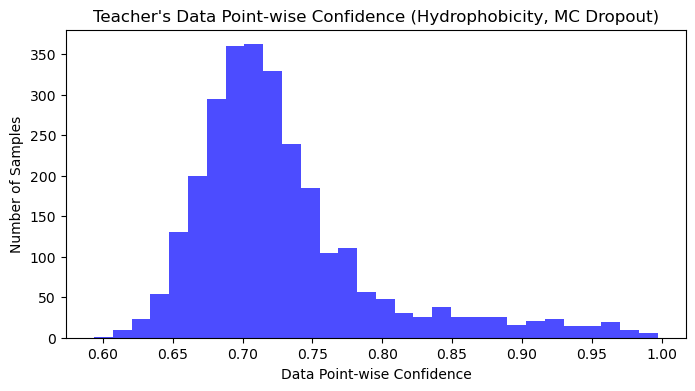

In [14]:
# CELL 7: RUN MC DROPOUT AND PLOT HISTOGRAM

datapoint_confidence = mc_dropout_predict_batchwise(
    teacher_model,
    train_data,
    n_iter=50
)

plt.figure(figsize=(8, 4))
plt.hist(datapoint_confidence, bins=30, alpha=0.7, color='blue')
plt.xlabel("Data Point-wise Confidence")
plt.ylabel("Number of Samples")
plt.title("Teacher's Data Point-wise Confidence (Hydrophobicity, MC Dropout)")
plt.show()

In [15]:
# CELL 8: SAVE CONFIDENCE SCORES AS .NPY

np.save("data_point_confidence.npy", datapoint_confidence)
print("Confidence scores saved to data_point_confidence.npy")

Confidence scores saved to data_point_confidence.npy


In [16]:
# CELL 9: PRINT CONFIDENCE VALUES

print("datapoint_confidence scores:", datapoint_confidence)
print("Confidence shape:", datapoint_confidence.shape)

datapoint_confidence scores: [0.7228144  0.6572689  0.7182213  ... 0.71491885 0.70432997 0.7040311 ]
Confidence shape: (2800,)


In [9]:
# CELL 10: DIVIDE DATASET INTO THREE CONFIDENCE REGIONS

import numpy as np

data_point_confidence = np.load("data_point_confidence.npy")
print("Confidence scores loaded")

all_data = []
all_labels = []

for i in range(len(train_data)):
    data_batch, label_batch = train_data[i]
    all_data.append(data_batch)
    all_labels.append(label_batch)

all_data = np.concatenate(all_data, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print("All data shape:", all_data.shape)
print("All labels shape:", all_labels.shape)
print("Confidence shape:", data_point_confidence.shape)

low_threshold = np.quantile(data_point_confidence, 1/3)
high_threshold = np.quantile(data_point_confidence, 2/3)

print(f"Low confidence threshold: {low_threshold}")
print(f"High confidence threshold: {high_threshold}")

low_confidence_indices = np.where(data_point_confidence <= low_threshold)[0]
medium_confidence_indices = np.where(
    (data_point_confidence > low_threshold) & (data_point_confidence <= high_threshold)
)[0]
high_confidence_indices = np.where(data_point_confidence > high_threshold)[0]

print(f"Low confidence samples count: {len(low_confidence_indices)}")
print(f"Medium confidence samples count: {len(medium_confidence_indices)}")
print(f"High confidence samples count: {len(high_confidence_indices)}")

low_confidence_data = all_data[low_confidence_indices]
low_confidence_labels = all_labels[low_confidence_indices]

medium_confidence_data = all_data[medium_confidence_indices]
medium_confidence_labels = all_labels[medium_confidence_indices]

high_confidence_data = all_data[high_confidence_indices]
high_confidence_labels = all_labels[high_confidence_indices]

Confidence scores loaded
All data shape: (2800, 224, 224, 3)
All labels shape: (2800, 7)
Confidence shape: (2800,)
Low confidence threshold: 0.6959987878799438
High confidence threshold: 0.7333441972732544
Low confidence samples count: 934
Medium confidence samples count: 933
High confidence samples count: 933


In [10]:
# CELL 11: SAVE LOW / MEDIUM / HIGH CONFIDENCE DATA AND LABELS AS .NPY

np.save("low_confidence_data.npy", low_confidence_data)
np.save("low_confidence_labels.npy", low_confidence_labels)

np.save("medium_confidence_data.npy", medium_confidence_data)
np.save("medium_confidence_labels.npy", medium_confidence_labels)

np.save("high_confidence_data.npy", high_confidence_data)
np.save("high_confidence_labels.npy", high_confidence_labels)

print("Subsets saved.")

Subsets saved.


In [11]:
# CELL 12: OPTIONAL SHAPE CHECKS

print("Low confidence data shape   :", low_confidence_data.shape)
print("Low confidence labels shape :", low_confidence_labels.shape)

print("Medium confidence data shape   :", medium_confidence_data.shape)
print("Medium confidence labels shape :", medium_confidence_labels.shape)

print("High confidence data shape   :", high_confidence_data.shape)
print("High confidence labels shape :", high_confidence_labels.shape)

Low confidence data shape   : (934, 224, 224, 3)
Low confidence labels shape : (934, 7)
Medium confidence data shape   : (933, 224, 224, 3)
Medium confidence labels shape : (933, 7)
High confidence data shape   : (933, 224, 224, 3)
High confidence labels shape : (933, 7)
